In [97]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt


In [98]:
with open('../tracker_stubs/ball_detections.pkl', 'rb') as f:
    ball_positions = pickle.load(f)


In [99]:
# print(type(ball_positions))
# print(type(ball_positions[0]))
# print(ball_positions[0])

print(len(ball_positions))
print(ball_positions[:5])

cleaned_positions = []

for x in ball_positions:
    if isinstance(x, dict):
        cleaned_positions.append(x.get(1, []))
    else:
        cleaned_positions.append(x)

ball_positions = cleaned_positions


# Convert list -> pandas DF:
df_ball_positions = pd.DataFrame(ball_positions, columns = ['x1', 'y1', 'x2', 'y2'])

# Interpolate missing values:

df_ball_positions = df_ball_positions.interpolate()
df_ball_positions = df_ball_positions.bfill()


214
[{}, {1: (884.9625244140625, 614.0418701171875, 914.2613525390625, 639.03759765625)}, {1: (873.3201293945312, 637.3963623046875, 898.1615600585938, 663.7112426757812)}, {1: (862.1157714843749, 642.4431640624999, 889.5789123535155, 668.6113708496093)}, {1: (854.9120690917968, 647.3972192382812, 880.7476971435547, 673.3672735595703)}]


In [100]:
df_ball_positions['mid_y'] = (df_ball_positions['y1'] + df_ball_positions['y2'])/2
df_ball_positions["mid_y_rolling_mean"] = df_ball_positions['mid_y'].rolling(window = 5, min_periods = 1, center = False).mean()

In [101]:
df_ball_positions['y1']
df_ball_positions['y2']

0      639.037598
1      639.037598
2      663.711243
3      668.611371
4      673.367274
          ...    
209    288.387430
210    288.387430
211    288.387430
212    288.387430
213    288.387430
Name: y2, Length: 214, dtype: float64

In [102]:
df_ball_positions[['y1', 'y2', 'mid_y']].head(20)

,y1,y2,mid_y
0,614.041870,639.037598,626.539734
1,614.041870,639.037598,626.539734
2,637.396362,663.711243,650.553802
3,642.443164,668.611371,655.527267
4,647.397219,673.367274,660.382246
5,664.943635,690.693067,677.818351
6,682.490051,708.018860,695.254456
7,690.043463,716.806329,703.424896
8,712.331848,739.785767,726.058807
9,712.225464,739.566860,725.896162


In [113]:
df_ball_positions['delta_y'].head(30)

0           NaN
1      0.000000
2      8.004690
3      5.245711
4      4.118422
5     10.255723
6     13.742944
7     10.574219
8     14.106308
9     13.102783
10     9.583033
11     6.063283
12    -2.291897
13   -13.539771
14   -22.100503
15   -29.504620
16   -31.715995
17   -32.180381
18   -29.800541
19   -25.548531
20   -22.453138
21   -24.550485
22   -21.706259
23   -19.086657
24   -17.724498
25   -15.841483
26   -13.764051
27   -11.954137
28   -11.810500
29   -10.799953
Name: delta_y, dtype: float64

In [103]:
df_ball_positions.head(5)

,x1,y1,x2,y2,mid_y,mid_y_rolling_mean
0,884.962524,614.041870,914.261353,639.037598,626.539734,626.539734
1,884.962524,614.041870,914.261353,639.037598,626.539734,626.539734
2,873.320129,637.396362,898.161560,663.711243,650.553802,634.544423
3,862.115771,642.443164,889.578912,668.611371,655.527267,639.790134
4,854.912069,647.397219,880.747697,673.367274,660.382246,643.908557


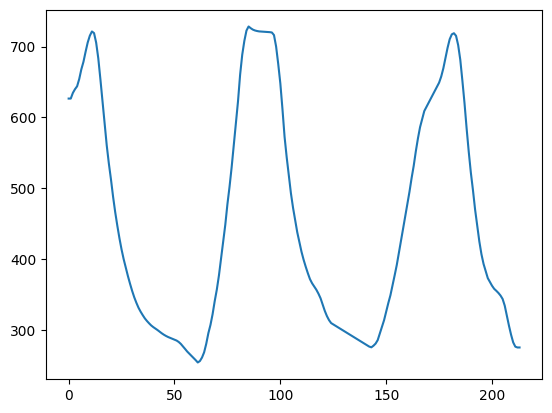

In [104]:
# Plotting the data:

plt.plot(df_ball_positions['mid_y_rolling_mean'])

In [105]:
df_ball_positions['delta_y'] = df_ball_positions['mid_y_rolling_mean'].diff()

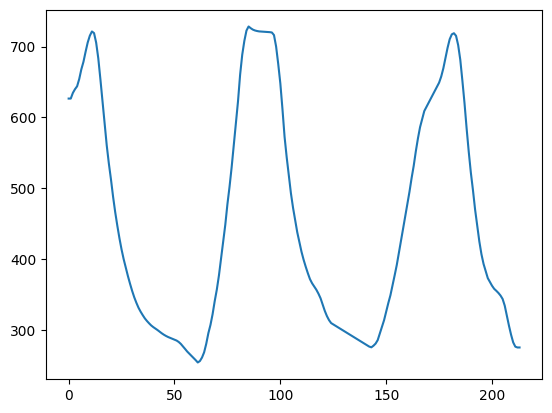

In [106]:
plt.plot(df_ball_positions['mid_y_rolling_mean'])

In [107]:
df_ball_positions["ball_hit"] = 0

In [ ]:
df_ball_positions['mid_y'] = (df_ball_positions['y1'] + df_ball_positions['y2'])/2
df_ball_positions["mid_y_rolling_mean"] = df_ball_positions['mid_y'].rolling(window = 5, min_periods = 1, center = False).mean()

minimum_change_frames_for_hit = 3
for i in range(1, len(df_ball_positions) - int(minimum_change_frames_for_hit * 1.2)):
    negative_position_change = df_ball_positions['delta_y'].iloc[i] > 0 and df_ball_positions['delta_y'].iloc[i + 1] < 0
    positive_position_change = df_ball_positions['delta_y'].iloc[i] < 0 and df_ball_positions['delta_y'].iloc[i + 1] > 0

    if negative_position_change or positive_position_change:
        change_count = 0
        for change_frame in range(i + 1, i + int(minimum_change_frames_for_hit * 1.2 ) + 1):
             negative_position_change_following_frame = df_ball_positions['delta_y'].iloc[i] > 0 and df_ball_positions['delta_y'].iloc[change_frame] < 0
             positive_position_change_following_frame = df_ball_positions['delta_y'].iloc[i] < 0 and df_ball_positions['delta_y'].iloc[change_frame] > 0

             if negative_position_change and negative_position_change_following_frame:
                 change_count += 1
             elif positive_position_change and positive_position_change_following_frame:
                 change_count += 1

        if change_count > minimum_change_frames_for_hit - 1:
            df_ball_positions['ball_hit'].iloc[i] = 1


frame_nums_with_ball_hits = df_ball_positions[df_ball_positions["ball_hit"] == 1].index.tolist()


C:\Users\Smoke Nandos\AppData\Local\Temp\ipykernel_21580\144456961.py:18: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  df_ball_positions['ball_hit'].iloc[i] = 1


In [117]:
print(df_ball_positions["delta_y"].min())
print(df_ball_positions["delta_y"].max())
print(df_ball_positions["delta_y"].describe())

-39.33110168457017
37.714315795898415
count    213.000000
mean      -1.650982
std       14.637848
min      -39.331102
25%       -9.113819
50%       -1.845852
75%        8.004690
max       37.714316
Name: delta_y, dtype: float64


In [120]:
print(df_ball_positions["ball_hit"].head(50).tolist())

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [121]:
print(df_ball_positions["ball_hit"].sum())

0


In [122]:
for i in range(1, 30):

    current = df_ball_positions['delta_y'].iloc[i]
    next_value = df_ball_positions['delta_y'].iloc[i + 1]

    print(i, current, next_value)

    if current > 0 and next_value < 0:
        print("Positive to negative detected")

    if current < 0 and next_value > 0:
        print("Negative to positive detected!")

1 0.0 8.004689534505246
2 8.004689534505246 5.245711008707644
3 5.245711008707644 4.118422393798824
4 4.118422393798824 10.255723419189394
5 10.255723419189394 13.742944335937523
6 13.742944335937523 10.57421875
7 10.57421875 14.106307983398438
8 14.106307983398438 13.102783101399723
9 13.102783101399723 9.583033091227321
10 9.583033091227321 6.063283081054578
11 6.063283081054578 -2.291896667480387
Positive to negative detected
12 -2.291896667480387 -13.539770507812477
13 -13.539770507812477 -22.10050313313809
14 -22.10050313313809 -29.50461954752609
15 -29.50461954752609 -31.715995483398387
16 -31.715995483398387 -32.180381164550795
17 -32.180381164550795 -29.800541381835842
18 -29.800541381835842 -25.54853149414066
19 -25.54853149414066 -22.453137817382753
20 -22.453137817382753 -24.550484619140718
21 -24.550484619140718 -21.706259155273415
22 -21.706259155273415 -19.08665740966802
23 -19.08665740966802 -17.72449795532225
24 -17.72449795532225 -15.84148280944828
25 -15.8414828094482

In [123]:
df_ball_positions["ball_hit"] = 0

for i in range(1, len(df_ball_positions) - 1):
    current = df_ball_positions['delta_y'].iloc[i]
    next_value = df_ball_positions['delta_y'].iloc[i + 1]

    if current > 0 and next_value < 0:
        print("HIT AT:", i)
        df_ball_positions.loc[i, "ball_hit"] = 1

    if current < 0 and next_value > 0:
        print("HIT AT:", i)
        df_ball_positions.loc[i, "ball_hit"] = 1

print(df_ball_positions["ball_hit"].sum())

HIT AT: 11
HIT AT: 61
HIT AT: 85
HIT AT: 143
HIT AT: 182
5


In [127]:
df_ball_positions[df_ball_positions["ball_hit"] == 1]

,x1,y1,x2,y2,mid_y,mid_y_rolling_mean,delta_y,ball_hit
11,778.463977,712.012695,803.539154,739.129047,725.570871,721.336851,6.063283,1
61,961.054463,237.194589,981.054463,257.194589,247.194589,253.686498,-3.329184,1
85,681.277732,710.157606,707.365000,737.390251,723.773929,728.389634,5.817212,1
143,821.171710,261.263535,848.301349,288.479028,274.871281,275.119699,-0.985030,1
182,1281.674533,695.006961,1308.864691,723.441779,709.224370,718.856937,1.602475,1


In [129]:
frame_nums_with_ball_hits = df_ball_positions[df_ball_positions["ball_hit"] == 1].index.tolist()